# Registration instructions

## Step 1: Ensure the main body direction is consistent

In [1]:
%cd ..
import openslide
import tifffile
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from module.KFBreader.kfbreader import KFBSlide
Image.MAX_IMAGE_PIXELS = None

/c23227/lwh/anaconda3/envs/aligner/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/c23227/lwh/code/XCellAligner


HE thumbnail size: (847, 1024)
MF thumbnail size: (1024, 878)


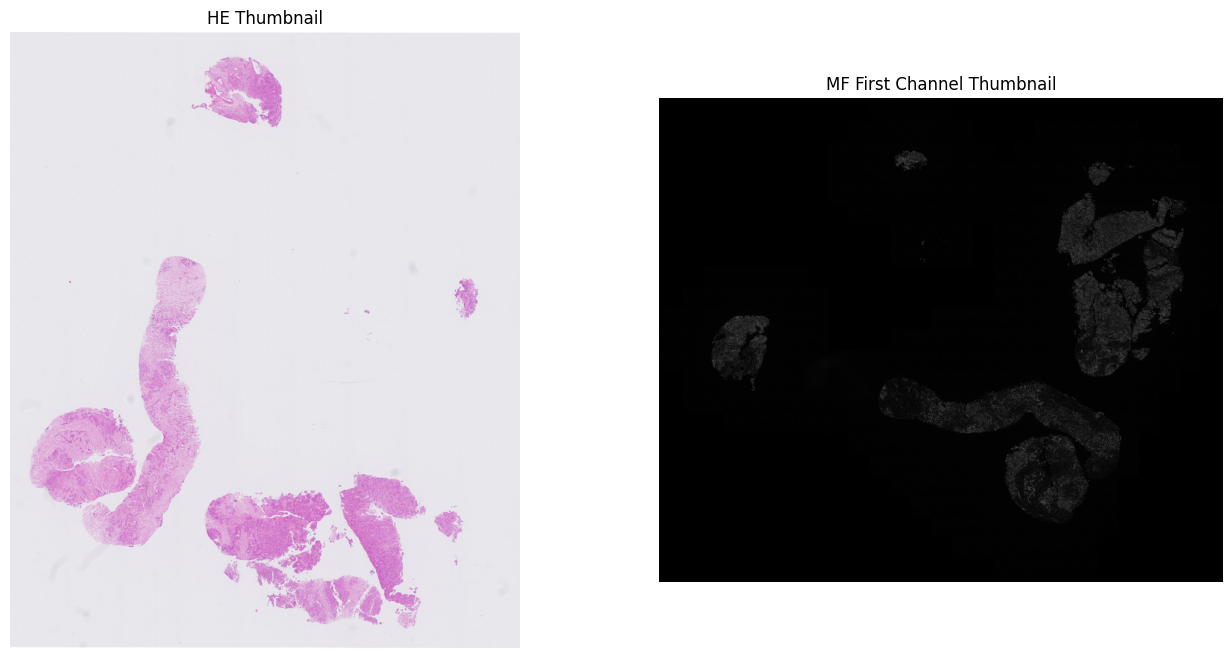

In [2]:
level = 4
he_slide = KFBSlide("/c23227/lwh/instructions/coarse_regis/data/he_origin.kfb")
width, height = he_slide.level_dimensions[level]
mf_slide = tifffile.imread("/c23227/lwh/instructions/coarse_regis/data/mif_DAPI.tif")

he_img = Image.fromarray(he_slide.read_region((0, 0), level, (width, height))).convert("RGB")
mf_img = Image.fromarray(mf_slide)

def resize_longest_edge(img, max_edge=1024):
    w, h = img.size
    scale = max_edge / max(w, h)
    new_size = (int(w * scale), int(h * scale))
    return img.resize(new_size, Image.LANCZOS)

he_thumbnail = resize_longest_edge(he_img)
mf_thumbnail = resize_longest_edge(mf_img)

print("HE thumbnail size:", he_thumbnail.size)
print("MF thumbnail size:", mf_thumbnail.size)

# 2. 用 plt 并排展示
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(np.array(he_thumbnail))
plt.axis('off')
plt.title("HE Thumbnail")

plt.subplot(1, 2, 2)
plt.imshow(np.array(mf_thumbnail), cmap='gray')
plt.axis('off')
plt.title("MF First Channel Thumbnail")

plt.show()

As you can see from the image above, the two slices are oriented differently. Therefore, please execute the following code to align their orientations:
```shell
python rotate_slide.py \
--input_path /c23227/lwh/instructions/coarse_regis/data/he_origin.kfb \
--output_path /c23227/lwh/instructions/coarse_regis/data/he_rotated.tiff \
--level 1 \
--angle 90 \
--back_color white
```
If you see "✅ Saved successfully: /c23227/lwh/instructions/coarse_regis/data/he_rotated.tiff", it means the rotation was successful.

HE thumbnail size: (1023, 847)
MF thumbnail size: (1024, 878)


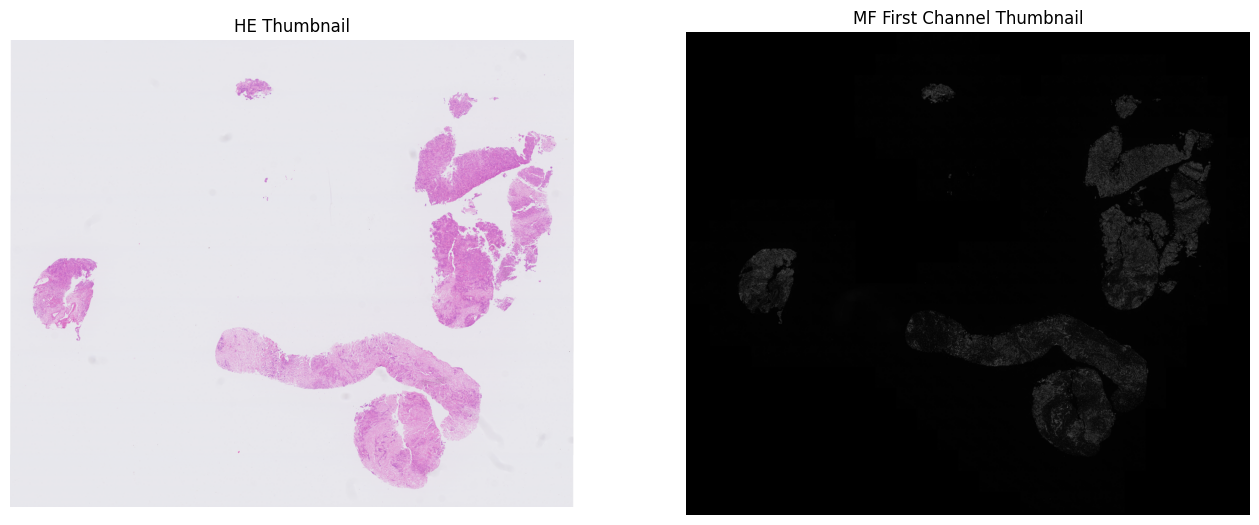

In [5]:
he_slide = tifffile.imread("/c23227/lwh/instructions/coarse_regis/data/he_rotated.tiff")
mf_slide = tifffile.imread("/c23227/lwh/instructions/coarse_regis/data/mif_DAPI.tif")

he_img = Image.fromarray(he_slide)
mf_img = Image.fromarray(mf_slide)

def resize_longest_edge(img, max_edge=1024):
    w, h = img.size
    scale = max_edge / max(w, h)
    new_size = (int(w * scale), int(h * scale))
    return img.resize(new_size, Image.LANCZOS)

he_thumbnail = resize_longest_edge(he_img)
mf_thumbnail = resize_longest_edge(mf_img)

print("HE thumbnail size:", he_thumbnail.size)
print("MF thumbnail size:", mf_thumbnail.size)

# 2. 用 plt 并排展示
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(np.array(he_thumbnail))
plt.axis('off')
plt.title("HE Thumbnail")

plt.subplot(1, 2, 2)
plt.imshow(np.array(mf_thumbnail), cmap='gray')
plt.axis('off')
plt.title("MF First Channel Thumbnail")

plt.show()

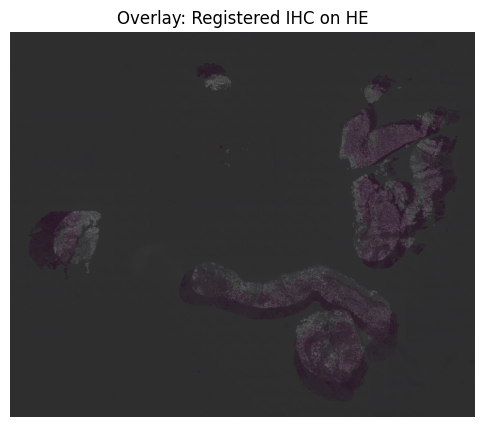

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(np.array(mf_thumbnail))  # 显示 HE 图像作为底图
plt.imshow(np.array(he_thumbnail), alpha=0.2)  # 覆盖 Registered IHC，设置透明度 0.5
plt.title("Overlay: Registered IHC on HE")
plt.axis("off")
plt.show()

Congratulations! You have now completed the initial orientation alignment, but as you can see, there is still misalignment between the slices. Next, we will perform more precise registration.

## Step 2: Thumbnail Level Registration

In [7]:
import os
os.environ["ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS"] = "32"  # 可根据 CPU 核心数调整

import SimpleITK as sitk
import numpy as np

# === 单通道 RGB 重采样函数 ===
def resample_rgb_image(image_np, reference_sitk, transform):
    registered_channels = []
    for i in range(3):
        channel = sitk.GetImageFromArray(image_np[..., i])
        channel.CopyInformation(reference_sitk)
        registered = sitk.Resample(channel, reference_sitk, transform, sitk.sitkLinear, 0.0)
        registered_channels.append(sitk.GetArrayFromImage(registered))
    return np.stack(registered_channels, axis=-1).astype(np.uint8)

# === warp RGB 图像用 displacement field ===
def warp_rgb_image(image_np, reference_sitk, transform):
    warped_channels = []
    for i in range(3):
        channel = sitk.GetImageFromArray(image_np[..., i])
        channel.CopyInformation(reference_sitk)
        warped = sitk.Resample(channel, reference_sitk, transform, sitk.sitkLinear, 0.0)
        warped_channels.append(sitk.GetArrayFromImage(warped))
    return np.stack(warped_channels, axis=-1).astype(np.uint8)

# === 主函数：带实时迭代反馈和日志写入 ===
def register_images_numpy(moving_rgb_np, fixed_rgb_np, log_file_path="/c23227/lwh/instructions/coarse_regis/log/registration_log.txt"):
    # 确保输入是3通道RGB图像
    if len(moving_rgb_np.shape) == 3 and moving_rgb_np.shape[2] == 3:
        moving_gray = np.dot(moving_rgb_np[...,:3], [0.2989, 0.5870, 0.1140])
    elif len(moving_rgb_np.shape) == 2:
        moving_gray = moving_rgb_np
    else:
        raise ValueError(f"移动图像形状不正确: {moving_rgb_np.shape}")
    
    if len(fixed_rgb_np.shape) == 3 and fixed_rgb_np.shape[2] == 3:
        fixed_gray = np.dot(fixed_rgb_np[...,:3], [0.2989, 0.5870, 0.1140])
    elif len(fixed_rgb_np.shape) == 2:
        fixed_gray = fixed_rgb_np
    else:
        raise ValueError(f"固定图像形状不正确: {fixed_rgb_np.shape}")
    
    # 归一化到0-1范围
    if moving_gray.max() > 1.0:
        moving_gray = moving_gray / 255.0
    if fixed_gray.max() > 1.0:
        fixed_gray = fixed_gray / 255.0
    
    # 确保值在合理范围内
    moving_gray = np.clip(moving_gray, 0, 1)
    fixed_gray = np.clip(fixed_gray, 0, 1)

    moving = sitk.GetImageFromArray((moving_gray * 255).astype(np.uint8))
    fixed = sitk.GetImageFromArray((fixed_gray * 255).astype(np.uint8))

    # 设置空间信息（单位像素间距，原点在左上角）
    fixed.SetOrigin((0.0, 0.0))
    fixed.SetSpacing((1.0, 1.0))
    moving.SetOrigin((0.0, 0.0))
    moving.SetSpacing((1.0, 1.0))

    # 高斯平滑降噪
    fixed = sitk.SmoothingRecursiveGaussian(fixed, sigma=1.5)
    moving = sitk.SmoothingRecursiveGaussian(moving, sigma=1.5)

    # 构建无旋转初始仿射变换（仅缩放 + 平移）
    initial_transform = sitk.AffineTransform(2)
    matrix = [1.05, 0.0,   # x方向允许略微缩放
              0.0, 1.00]   # y方向不变
    initial_transform.SetMatrix(matrix)

    # 对齐图像中心
    def get_center(image):
        size = image.GetSize()
        return np.array([size[0] / 2.0, size[1] / 2.0])

    center_moving = get_center(moving)
    center_fixed = get_center(fixed)
    translation = center_fixed - center_moving
    initial_transform.SetTranslation([translation[0], translation[1]])

    # 配准设置
    registration_method = sitk.ImageRegistrationMethod()
    registration_method.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
    registration_method.SetMetricSamplingStrategy(registration_method.RANDOM)
    registration_method.SetMetricSamplingPercentage(1.0)
    registration_method.SetInterpolator(sitk.sitkLinear)

    # 优化器设置
    registration_method.SetOptimizerAsRegularStepGradientDescent(
        learningRate=1.5,
        minStep=1e-6,
        numberOfIterations=5000,
        gradientMagnitudeTolerance=1e-6
    )
    registration_method.SetOptimizerScalesFromPhysicalShift()

    registration_method.SetInitialTransform(initial_transform, inPlace=False)

    # === 添加迭代回调：实时打印并记录到文件 ===
    iteration_data = []

    # 打开日志文件（在回调外打开，避免重复开闭）
    if log_file_path != None:
        log_file = open(log_file_path, 'w')
        log_file.write("Iteration,MetricValue\n")  # CSV header

    def iteration_callback():
        current_iter = registration_method.GetOptimizerIteration()
        metric_val = registration_method.GetMetricValue()
        lr = registration_method.GetOptimizerLearningRate()
        iteration_data.append({
            'iteration': current_iter,
            'metric_value': metric_val,
            'learning_rate': lr
        })
        if current_iter % 100 == 0:
            print(f"Iteration {current_iter:4d}: Metric={metric_val:.6f}, LR={lr:.6f}", flush=True)
        # 写入日志文件（CSV格式）
        if log_file_path != None:
            log_file.write(f"{current_iter},{metric_val:.6f}\n")
            log_file.flush()  # 确保立即写入磁盘

    registration_method.AddCommand(sitk.sitkIterationEvent, iteration_callback)

    try:
        # === 刚性配准执行 ===
        print("Starting rigid registration...")
        final_transform = registration_method.Execute(fixed, moving)
        print("Rigid registration finished.\n")
    finally:
        if log_file_path != None:
            log_file.close()  # 确保无论是否出错都关闭文件

    # === 应用刚性变换到 RGB 图像 ===
    registered_rigid = resample_rgb_image(moving_rgb_np, fixed, final_transform)

    # === 非刚性微调（Demons）===
    moving_gray_registered = sitk.Resample(moving, fixed, final_transform, sitk.sitkLinear, 0.0)
    demons = sitk.DemonsRegistrationFilter()
    demons.SetNumberOfIterations(80)
    demons.SetStandardDeviations(1.0)
    displacement_field = demons.Execute(fixed, moving_gray_registered)

    # 创建位移场变换
    displacement_tx = sitk.DisplacementFieldTransform(displacement_field)
    displacement_tx.SetSmoothingGaussianOnUpdate(0.0, 1.0)

    # 应用非刚性变换到 RGB 图像
    registered_final = warp_rgb_image(registered_rigid, fixed, displacement_tx)

    return {
        'RegisteredImage': registered_final,
        'RigidResult': registered_rigid,
        'Transformation': final_transform,
        'DisplacementField': displacement_field,
        'IterationHistory': iteration_data  # 包含每轮迭代信息
    }

匹配尺寸为(1024, 878)
Starting rigid registration...
Iteration    0: Metric=-0.163519, LR=1.500000
Iteration  100: Metric=-0.469601, LR=1.500000
Iteration  200: Metric=-0.545705, LR=1.500000
Iteration  300: Metric=-0.582112, LR=1.500000
Iteration  400: Metric=-0.584776, LR=1.500000
Iteration  500: Metric=-0.584870, LR=1.500000
Iteration  600: Metric=-0.584880, LR=1.500000
Rigid registration finished.

Finished match


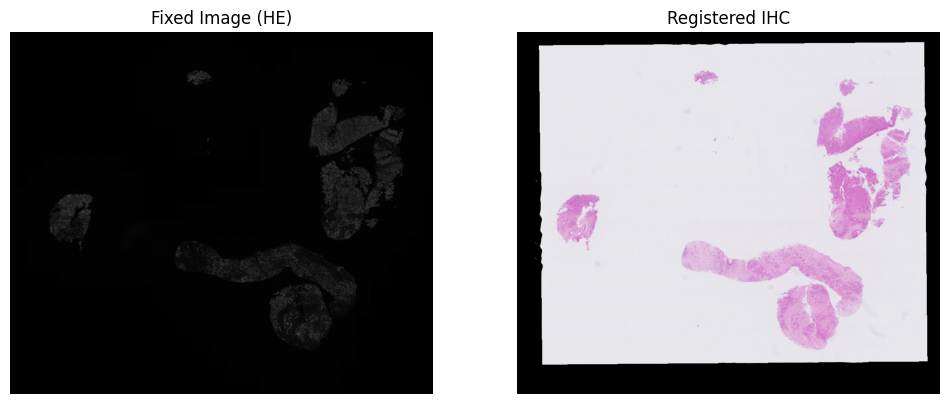

In [8]:
from skimage.transform import resize

def resize_to_match(img1, img2):
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    target_h = max(h1, h2)
    target_w = max(w1, w2)

    print(f"匹配尺寸为({str(target_w)}, {str(target_h)})")

    img1_resized = resize(img1, (target_h, target_w), preserve_range=True).astype(img1.dtype)
    img2_resized = resize(img2, (target_h, target_w), preserve_range=True).astype(img2.dtype)

    return img1_resized, img2_resized, target_w, target_h

fixed_img, moving_img, resized_width, resized_height = resize_to_match(np.array(mf_thumbnail), np.array(he_thumbnail))

result = register_images_numpy(moving_img, fixed_img, None)

print("Finished match")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) 
plt.imshow(mf_thumbnail)
plt.title("Fixed Image (HE)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result['RegisteredImage'].astype(np.uint8))
plt.title("Registered IHC")
plt.axis("off")
plt.show()

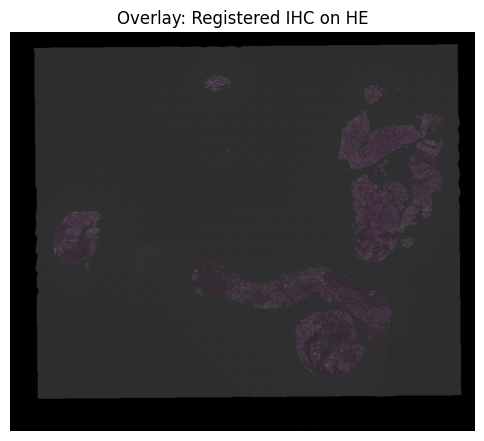

In [9]:
plt.figure(figsize=(6, 6))
plt.imshow(fixed_img)
plt.imshow(result['RegisteredImage'].astype(np.uint8), alpha=0.2)
plt.title("Overlay: Registered IHC on HE")
plt.axis("off")
plt.show()

Congratulations! You have now completed the slice-level registration. Next, we will align the patch level.

## Step 3. Patch Level Registration

In [18]:
import time
import functools
from datetime import datetime
import numpy as np
from PIL import Image

def log_time_stage(func):
    """装饰器：记录函数执行过程中各阶段的时间"""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        start_total = time.time()
        print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 开始执行函数: {func.__name__}")
        
        try:
            result = func(*args, **kwargs)
            end_total = time.time()
            print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 函数 {func.__name__} 执行完成，总耗时: {end_total - start_total:.4f}秒")
            return result
        except Exception as e:
            end_total = time.time()
            print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 函数 {func.__name__} 执行出错，总耗时: {end_total - start_total:.4f}秒")
            raise e
    
    # 创建子装饰器来记录特定步骤
    def log_step(step_name):
        def step_decorator(step_func):
            @functools.wraps(step_func)
            def step_wrapper(*s_args, **s_kwargs):
                start = time.time()
                print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 开始执行步骤: {step_name}")
                
                result = step_func(*s_args, **s_kwargs)
                
                end = time.time()
                print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 步骤 {step_name} 完成，耗时: {end - start:.4f}秒")
                return result
            return step_wrapper
        return step_decorator
    
    wrapper.log_step = log_step
    return wrapper

@log_time_stage
def map_patch_he_to_mif(
    mif_patch_x, mif_patch_y, patch_width, patch_height,
    he_slide,
    transform,
    mif_thumb_size, mif_orig_size,
    he_thumb_size, he_orig_size
):
    """
    用自定义的缩略图尺寸和原图尺寸计算缩放比例，映射 HE 原图 patch 到配准后的 IHC 原图 patch。

    参数：
    - mif_patch_x, mif_patch_y: mIF 原图 (level 0) patch 左上角坐标
    - patch_width, patch_height: patch 宽高，单位像素（原图尺寸）
    - he_slide: slide 对象（用于读取 patch）
    - transform: SimpleITK 变换（刚性或非刚性）
    - mif_thumb_size: (w, h) mIF 缩略图尺寸（配准时使用的尺寸）
    - mif_orig_size: (w, h) mIF 原图尺寸
    - he_thumb_size: (w, h) HE 缩略图尺寸（配准时使用的尺寸）
    - he_orig_size: (w, h) HE 原图尺寸

    返回：
    - he_patch_img: PIL.Image 对象，HE 原图对应 patch
    - he_patch_coords: (x, y, w, h) 在 HE 原图上的坐标
    """

    # 计算缩放比例（原图 / 缩略图）
    start_calc_ratio = time.time()
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 开始计算缩放比例")
    
    mif_downsample_x = mif_orig_size[0] / mif_thumb_size[0]
    mif_downsample_y = mif_orig_size[1] / mif_thumb_size[1]
    he_downsample_x = he_orig_size[0] / he_thumb_size[0]
    he_downsample_y = he_orig_size[1] / he_thumb_size[1]

    end_calc_ratio = time.time()
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 缩放比例计算完成，耗时: {end_calc_ratio - start_calc_ratio:.4f}秒")

    # 原图 mIF patch 坐标 → 缩略图坐标 (x 和 y 分别计算)
    start_coord_transform = time.time()
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 开始坐标转换（mIF原图→缩略图）")
    
    x_thumb = mif_patch_x / mif_downsample_x
    y_thumb = mif_patch_y / mif_downsample_y
    w_thumb = patch_width / mif_downsample_x
    h_thumb = patch_height / mif_downsample_y

    end_coord_transform = time.time()
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 坐标转换（mIF原图→缩略图）完成，耗时: {end_coord_transform - start_coord_transform:.4f}秒")

    # 计算 patch 四个角点（缩略图坐标）
    start_corner_calc = time.time()
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 开始计算四个角点坐标")
    
    corners = np.array([
        [x_thumb, y_thumb],
        [x_thumb + w_thumb, y_thumb],
        [x_thumb, y_thumb + h_thumb],
        [x_thumb + w_thumb, y_thumb + h_thumb]
    ])

    end_corner_calc = time.time()
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 角点坐标计算完成，耗时: {end_corner_calc - start_corner_calc:.4f}秒")

    # 应用配准变换
    start_transform = time.time()
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 开始应用配准变换")
    
    transformed_corners = []
    for i, pt in enumerate(corners):
        transform_start = time.time()
        transformed = transform.TransformPoint((float(pt[0]), float(pt[1])))
        transform_end = time.time()
        print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 第{i+1}个点变换完成，耗时: {transform_end - transform_start:.4f}秒")
        transformed_corners.append(transformed)
    transformed_corners = np.array(transformed_corners)

    end_transform = time.time()
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 配准变换完成，总耗时: {end_transform - start_transform:.4f}秒")

    # 缩略图坐标转换回 HE 原图坐标（x 和 y 分别计算）
    start_back_transform = time.time()
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 开始坐标转换（缩略图→HE原图）")
    
    he_corners_level0 = np.empty_like(transformed_corners)
    he_corners_level0[:, 0] = transformed_corners[:, 0] * he_downsample_x
    he_corners_level0[:, 1] = transformed_corners[:, 1] * he_downsample_y

    end_back_transform = time.time()
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 坐标转换（缩略图→HE原图）完成，耗时: {end_back_transform - start_back_transform:.4f}秒")

    # 包围盒转整数坐标
    start_bbox = time.time()
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 开始计算包围盒坐标")
    
    min_x = int(np.floor(np.min(he_corners_level0[:, 0])))
    min_y = int(np.floor(np.min(he_corners_level0[:, 1])))
    max_x = int(np.ceil(np.max(he_corners_level0[:, 0])))
    max_y = int(np.ceil(np.max(he_corners_level0[:, 1])))

    end_bbox = time.time()
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 包围盒坐标计算完成，耗时: {end_bbox - start_bbox:.4f}秒")

    # 从 IHC 原图读取对应 patch
    start_read_patch = time.time()
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 开始读取HE patch")
    
    he_patch_img = he_slide.crop((min_x, min_y, max_x, max_y))
    he_patch_img = he_patch_img.resize((patch_width, patch_height), resample=Image.BILINEAR)

    end_read_patch = time.time()
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] HE patch读取完成，耗时: {end_read_patch - start_read_patch:.4f}秒")

    return he_patch_img, (min_x, min_y, 512, 512)

In [19]:
level = 0
(width, height) = mf_img.size
(he_width, he_height) = he_img.size

print(f"多重荧光尺寸为: {width}×{height}")
print(f"HE尺寸为: {he_width}×{he_height}")

# patch 参数
mif_patch_x = 35000
mif_patch_y = 32000
patch_width = 512
patch_height = 512

full_transform = result['Transformation']
he_slide_img = Image.fromarray(he_slide)

he_patch_img, he_patch_coords = map_patch_he_to_mif(
    mif_patch_x=mif_patch_x, mif_patch_y=mif_patch_y,
    patch_width=patch_width, patch_height=patch_height,
    he_slide=he_slide_img,
    transform=full_transform,  # 或 displacement_tx
    mif_thumb_size=(resized_width, resized_height),
    mif_orig_size=(width, height),
    he_thumb_size=(resized_width, resized_height),
    he_orig_size=(he_width, he_height),
)

多重荧光尺寸为: 52224×44800
HE尺寸为: 22049×18241
[2026-03-14 11:15:54] 开始执行函数: map_patch_he_to_mif
[2026-03-14 11:15:54] 开始计算缩放比例
[2026-03-14 11:15:54] 缩放比例计算完成，耗时: 0.0000秒
[2026-03-14 11:15:54] 开始坐标转换（mIF原图→缩略图）
[2026-03-14 11:15:54] 坐标转换（mIF原图→缩略图）完成，耗时: 0.0000秒
[2026-03-14 11:15:54] 开始计算四个角点坐标
[2026-03-14 11:15:54] 角点坐标计算完成，耗时: 0.0000秒
[2026-03-14 11:15:54] 开始应用配准变换
[2026-03-14 11:15:54] 第1个点变换完成，耗时: 0.0002秒
[2026-03-14 11:15:54] 第2个点变换完成，耗时: 0.0000秒
[2026-03-14 11:15:54] 第3个点变换完成，耗时: 0.0000秒
[2026-03-14 11:15:54] 第4个点变换完成，耗时: 0.0000秒
[2026-03-14 11:15:54] 配准变换完成，总耗时: 0.0002秒
[2026-03-14 11:15:54] 开始坐标转换（缩略图→HE原图）
[2026-03-14 11:15:54] 坐标转换（缩略图→HE原图）完成，耗时: 0.0000秒
[2026-03-14 11:15:54] 开始计算包围盒坐标
[2026-03-14 11:15:54] 包围盒坐标计算完成，耗时: 0.0001秒
[2026-03-14 11:15:54] 开始读取HE patch
[2026-03-14 11:15:54] HE patch读取完成，耗时: 0.0022秒
[2026-03-14 11:15:54] 函数 map_patch_he_to_mif 执行完成，总耗时: 0.0028秒


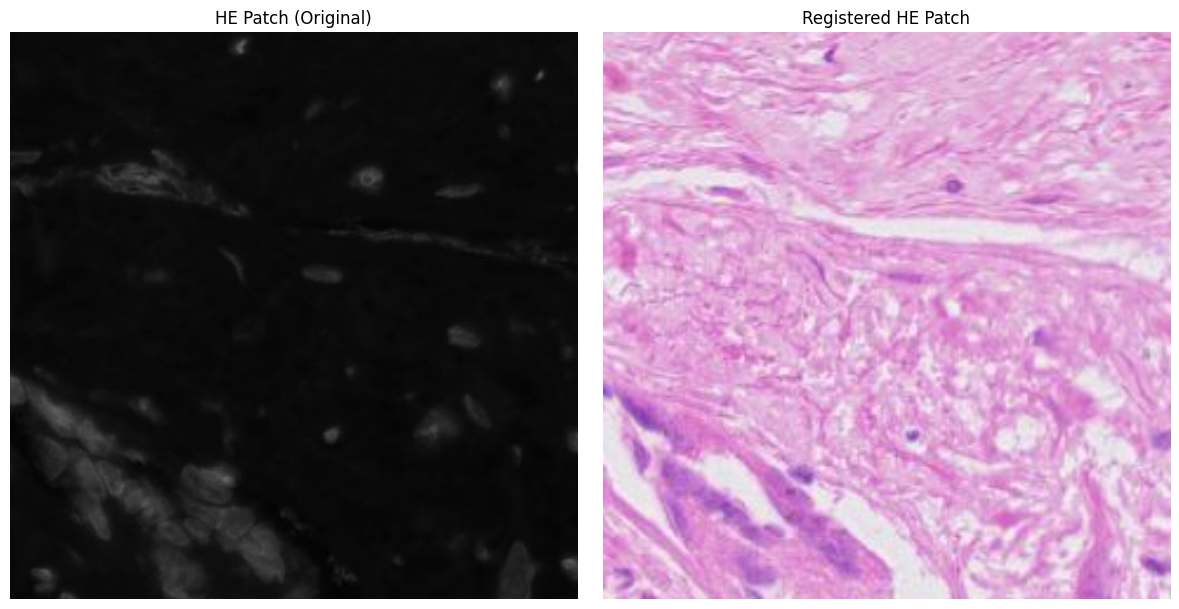

In [20]:
x = mif_patch_x
y = mif_patch_y
mf_patch = mf_img.crop((x, y, x + patch_width, y + patch_height))

# matplotlib 可视化
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(mf_patch, cmap='gray')
plt.title("HE Patch (Original)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(he_patch_img)
plt.title("Registered HE Patch")
plt.axis("off")

plt.tight_layout()
plt.show()

Congratulations! You have now completed the patch-level registration. Next, execute get_mIF_patch.py ​​(this is an example and needs to be adjusted according to your actual situation). Record all the coordinates (patch_coords.json) of the mIF and transform them to the coordinates of the HE slice.

In [ ]:
import json
from tqdm import tqdm

json_path = '/c23227/lwh/instructions/coarse_regis/data/patch_coords.json'

with open(json_path, "r") as f:
    coords_list = json.load(f)

for coord in tqdm(coords_list):
    dapi_patch_x, dapi_patch_y = coord["x"], coord["y"]
    mf_patch = mf_img.crop((coord["x"], coord["y"], coord["x"] + patch_width, coord["y"] + patch_height))
    mf_np = np.array(mf_patch)
    if np.mean(mf_np) < 5:
        continue
    ihc_patch_img, ihc_patch_coords = map_patch_he_to_mif(
        he_patch_x=dapi_patch_x, he_patch_y=dapi_patch_y,
        patch_width=patch_width, patch_height=patch_height,
        ihc_slide=he_slide_img,
        transform=full_transform,  # 或 displacement_tx
        he_thumb_size=(resized_width, resized_height),
        he_orig_size=(width, height),
        ihc_thumb_size=(resized_width, resized_height),
        ihc_orig_size=(he_width, he_height),
    )

    ihc_patch_img.save(os.path.join('/c23227/lwh/instructions/coarse_regis/data/patch/he', f"he_x{dapi_patch_x}_y{dapi_patch_y}.png"))